# LSTM Model Incorporating Price and Eight Additional Covariates (Observed Data)

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import os
import random
import itertools
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
import importlib
import my_lstm
importlib.reload(my_lstm)

from my_lstm import build_lstm_model, create_sequences, expanding_window_lstm_forecast


In [24]:
# import data set
df = pd.read_csv('../data/final_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

In [25]:
df.head()

,Date,AUD_USD_ret,CAD_USD_ret,NZD_USD_ret,ZAR_USD_ret,CPI,TB3MS,M1,M2,wti_ret
0,1986-02-01,-0.001030,-0.001919,0.029004,-0.122803,-0.005468,-0.01,0.003518,0.000302,-0.394190
1,1986-03-01,0.012299,-0.002406,-0.006743,-0.023616,-0.003663,-0.50,0.007092,0.003699,-0.203766
2,1986-04-01,0.020833,-0.009353,0.060724,0.005213,0.001811,-0.50,-0.001419,0.001697,0.018075
3,1986-05-01,0.006006,-0.008792,0.009556,0.067115,0.006429,0.09,0.005246,0.000797,0.180503
4,1986-06-01,-0.054147,0.010266,-0.037406,0.144931,0.000907,0.06,-0.003911,-0.002716,-0.135577


In [26]:
feature_cols = [
    "AUD_USD_ret",
    "CAD_USD_ret",
    "NZD_USD_ret",
    "ZAR_USD_ret",
    "CPI",
    "TB3MS",
    "M1",
    "M2", 
    "wti_ret"
]

target_col = "wti_ret"

In [27]:
# data split into 70/15/15
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)
val_end = train_size + val_size

train_data = df.iloc[:train_size]
val_data = df.iloc[train_size:val_end]
test_data = df.iloc[val_end:]

# print length of data in each set
print(f'Train data length: {len(train_data)}')
print(f'Validation data length: {len(val_data)}')
print(f'Test data length: {len(test_data)}')

Train data length: 336
Validation data length: 72
Test data length: 72


In [28]:
# grid search over hyperparameters for the expanding window LSTM
param_grid_tiny = {
    "lookback": [2, 10],
    "dropout": [0.001, 0.1],
    "units": [50, 170],
    "epochs": [50, 100]
} 
param_combinations = list(itertools.product(
    param_grid_tiny["lookback"],
    param_grid_tiny["dropout"],
    param_grid_tiny["units"],
    param_grid_tiny["epochs"]
))

results_grid = []

for i, (lb, dr, units, ep) in enumerate(param_combinations, 1):
    print(f"\n[{i}/{len(param_combinations)}] Testing params:")
    print(f"lookback={lb}, dropout={dr}, units={units}, epochs={ep}")

    try:
        val_forecasts = expanding_window_lstm_forecast(
            df=df,
            feature_cols=feature_cols,
            target_col=target_col,
            initial_train_size=train_size,
            end_idx=val_end,
            date_col="Date",
            lookback=lb,
            units=units,
            dropout=dr,
            epochs=ep,
            batch_size=32,
            verbose=0,
            scale=True,
            seed=42
        )

        if len(val_forecasts) == 0:
            print("No forecasts generated, skipping.")
            continue

        mse = mean_squared_error(
            val_forecasts["actual"],
            val_forecasts["predicted"]
        )

        print(f"Validation MSE: {mse:.6f}")

        results_grid.append({
            "lookback": lb,
            "dropout": dr,
            "units": units,
            "epochs": ep,
            "mse": mse
        })

    except Exception as e:
        print(f"Error: {e}")
        continue



[1/16] Testing params:
lookback=2, dropout=0.001, units=50, epochs=50


2026-03-28 01:50:46.237587: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Validation MSE: 0.374146

[2/16] Testing params:
lookback=2, dropout=0.001, units=50, epochs=100
Error: Graph execution error:

Detected at node 'truediv_7' defined at (most recent call last):
    File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/ipykernel_launcher.py", line 17, in <module>
      app.launch_new_instance()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
      app.start()
    File "/Users/jasonlow/Library/Python/3.10/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start
      self.io_loop.start()
    File "/Users/jasonlow/Library/Python/3.10/lib/python

In [29]:
results_grid

[{'lookback': 2,
  'dropout': 0.001,
  'units': 50,
  'epochs': 50,
  'mse': 0.37414601603980924},
 {'lookback': 2,
  'dropout': 0.001,
  'units': 170,
  'epochs': 100,
  'mse': 1.193213817990087},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 50,
  'epochs': 100,
  'mse': 0.4810743525290989},
 {'lookback': 2,
  'dropout': 0.1,
  'units': 170,
  'epochs': 100,
  'mse': 0.8210179135074424},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 50,
  'epochs': 100,
  'mse': 0.6919933957193808},
 {'lookback': 10,
  'dropout': 0.001,
  'units': 170,
  'epochs': 100,
  'mse': 0.6318359660201163},
 {'lookback': 10,
  'dropout': 0.1,
  'units': 50,
  'epochs': 50,
  'mse': 0.46495415832342285},
 {'lookback': 10,
  'dropout': 0.1,
  'units': 50,
  'epochs': 100,
  'mse': 0.5351602747310689},
 {'lookback': 10,
  'dropout': 0.1,
  'units': 170,
  'epochs': 50,
  'mse': 0.6261621048707029},
 {'lookback': 10,
  'dropout': 0.1,
  'units': 170,
  'epochs': 100,
  'mse': 0.5768440024365281}]

In [30]:
results_df = pd.DataFrame(results_grid)
results_df = results_df.sort_values("mse")

print(results_df.head())

best_params = results_df.iloc[0]
print(best_params)

   lookback  dropout  units  epochs       mse
0         2    0.001     50      50  0.374146
6        10    0.100     50      50  0.464954
2         2    0.100     50     100  0.481074
7        10    0.100     50     100  0.535160
9        10    0.100    170     100  0.576844
lookback     2.000000
dropout      0.001000
units       50.000000
epochs      50.000000
mse          0.374146
Name: 0, dtype: float64


# Out of sample forecast

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score

In [40]:
# best parameters from validation
#best_params = {}
#best_params["lookback"] = 2.0
#best_params["dropout"] = 0.001
#best_params["units"] = 50.0
#best_params["epochs"] = 50.0

# comment out if already tuned and just want to run test evaluation with best params

test_results = expanding_window_lstm_forecast(
    df=df,
    feature_cols=feature_cols,
    target_col=target_col,
    initial_train_size=val_end,  
    end_idx=len(df),    
    date_col="Date",        
    lookback=int(best_params["lookback"]),
    units=int(best_params["units"]),
    dropout=float(best_params["dropout"]),
    epochs=int(best_params["epochs"]),
    batch_size=32,
    verbose=0,
    scale=True,
    seed=42
)

test_mse = mean_squared_error(
    test_results["actual"],
    test_results["predicted"]
)

test_mape = mean_absolute_percentage_error(
    test_results["actual"],
    test_results["predicted"]
)

test_r2 = r2_score(
    test_results["actual"],
    test_results["predicted"]
)

print("Test MSE:", test_mse)
print("Test MAPE:", test_mape)
print("Test R²:", test_r2)


Test MSE: 0.16200081010043993
Test MAPE: 11.65513898887871
Test R²: -7.5497516339838295


In [41]:
test_results.head()

,test_index,actual,predicted,Date
0,408,-0.129368,0.021796,2020-02-01
1,409,-0.548254,-0.562555,2020-03-01
2,410,-0.568125,-1.147854,2020-04-01
3,411,0.545621,0.604506,2020-05-01
4,412,0.293704,2.252935,2020-06-01


In [43]:
# export test results to csv
#test_results.to_csv('results/lstm8_test_results.csv', index=False)

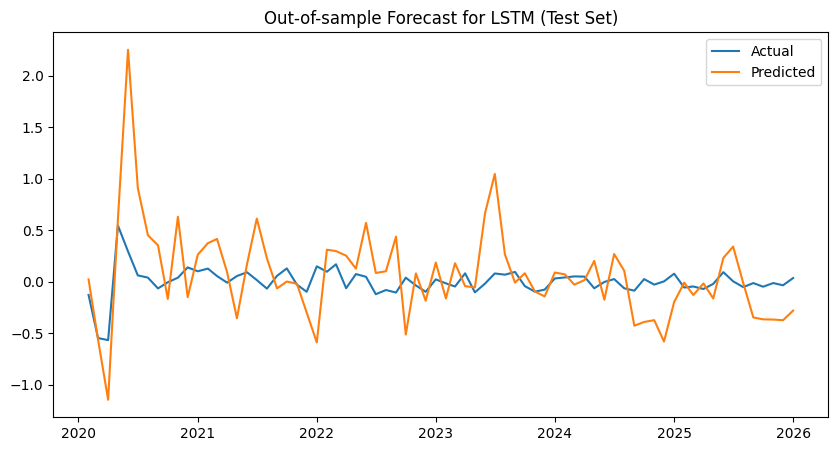

In [44]:
plt.figure(figsize=(10,5))
plt.plot(test_results['Date'], test_results["actual"], label="Actual")
plt.plot(test_results['Date'], test_results["predicted"], label="Predicted")
plt.legend()
plt.title("Out-of-sample Forecast for LSTM (Test Set)")
plt.show()